# EB 기준선: Top-k·파서·지원량 감사

P1+Empirical-Bayes 기준선을 변경하지 않고, top-k oracle·margin·파서 coverage와 후속 구조 피처 지원량을 train OOF로 확인합니다. 실행기는 train만 읽으며 test 데이터는 참조하지 않습니다.


In [2]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "experiments/gs/notebooks/exp_model_003/common/run_p1_eb_axis.py").exists())
COMMON = ROOT / "experiments/gs/notebooks/exp_model_003/common"
RESULT = ROOT / "experiments/gs/notebooks/exp_model_003/result"
RUNNER = COMMON / "run_p1_eb_axis.py"
assert RUNNER.exists(), RUNNER


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42
RUN_EXPERIMENT = True  # 전체 OOF 실행 전에는 False로 둘 수 있습니다.
RUN_ID = "exp-eb-topk-parser-audit-01"

if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), "--axis", "audit", "--seed", str(SEED), "--run-id", RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc="OOF runner", unit="line"):
        print(line, end="")
        tail = (tail + [line])[-120:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f"runner failed (exit={return_code}). Last runner output:\n" + "".join(tail))
else:
    print("RUN_EXPERIMENT=False: 기존 결과만 조회합니다.")


OOF runner: 2line [00:05,  2.48s/line]


row-local mutation cache:   0%|          | 0/4384 [00:00<?, ?it/s]


OOF runner: 4line [00:06,  1.13line/s]

row-local mutation cache:   2%|▏         | 76/4384 [00:00<00:12, 350.06it/s]


OOF runner: 6line [00:06,  2.27line/s]

...

OOF runner: 110line [00:17,  9.88line/s]

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 387.99it/s]


OOF runner: 115line [01:38, 10.01s/line]

 macro_recall_at_1  oracle_macro_f1_at_1  macro_recall_at_2  oracle_macro_f1_at_2  macro_recall_at_3  oracle_macro_f1_at_3
          0.555951              0.533385           0.688918              0.671854           0.767623              0.752101
runtime_seconds=97.76


OOF runner: 115line [01:39,  1.16line/s]


,macro_recall_at_1,oracle_macro_f1_at_1,macro_recall_at_2,oracle_macro_f1_at_2,macro_recall_at_3,oracle_macro_f1_at_3,seed,oof_macro_f1,convergence_warning_count,leakage_check,nan_as_mutation_count
0,0.555951,0.533385,0.688918,0.671854,0.767623,0.752101,42,0.533385,0,True,0


,event_type,count,rate
0,FRAMESHIFT,9542,0.043592
1,INFRAME_DEL,3,0.000014
2,MISSENSE,178415,0.815079
3,NONSENSE,12821,0.058572
4,OTHER,18112,0.082744


,gene,event_count,same_codon,position_span


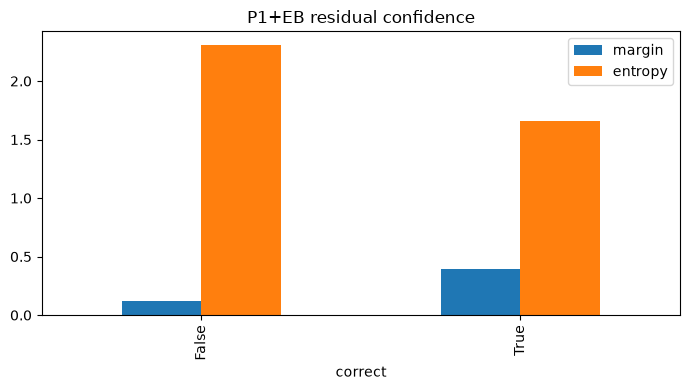

In [4]:
from pandas.errors import EmptyDataError

def read_csv_or_empty(path, columns):
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)

summary = pd.read_csv(RESULT / f"exp-eb-topk-parser-audit-01_seed{SEED}_summary.csv")
rank_rows = pd.read_csv(RESULT / f"exp-eb-topk-parser-audit-01_seed{SEED}_rank_rows.csv")
coverage = pd.read_csv(RESULT / f"exp-eb-topk-parser-audit-01_seed{SEED}_parser_coverage.csv")
support = read_csv_or_empty(
    RESULT / f"exp-eb-topk-parser-audit-01_seed{SEED}_structure_support.csv",
    ["gene", "event_count", "same_codon", "position_span"],
)
display(summary); display(coverage); display(support.head(20))
assert int(summary.nan_as_mutation_count.iloc[0]) == 0
assert bool(summary.leakage_check.iloc[0])
if "correct" not in rank_rows:
    rank_rows["correct"] = rank_rows["true_class"].eq(rank_rows["top1_class"])
rank_rows.groupby("correct")[["margin", "entropy"]].mean().plot.bar(figsize=(7, 4), title="P1+EB residual confidence")
plt.tight_layout(); plt.show()
